In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🟢 STEP 4 — Pandas Se Dataset Load Karo

In [3]:
import pandas as pd

df = pd.read_csv(
    "C:/Users/rudra/OneDrive/Desktop/data science/Machine learning/Ecommerce_Sales_Intelligence/data/ecommerce.csv"
)

df.head()

,Order_ID,Customer_ID,Date,Gender,Age,City,Product,Category,Quantity,Price,Discount,Payment_Method
0,ORD0001,CUST004,2025-02-27,Female,33,Vadodara,Wallet,Accessories,2,999,0,Net Banking
1,ORD0002,CUST055,2025-10-30,Male,19,Pune,Smartphone,Electronics,2,30000,5,Net Banking
2,ORD0003,CUST072,2025-01-14,Male,59,Jaipur,Watch,Accessories,4,3999,5,Cash on Delivery
3,ORD0004,CUST001,2025-05-23,Male,45,Delhi,Watch,Accessories,3,3999,5,Credit Card
4,ORD0005,CUST014,2025-06-22,Male,42,Pune,Book,Books,3,499,10,Net Banking


In [4]:
df.tail()

,Order_ID,Customer_ID,Date,Gender,Age,City,Product,Category,Quantity,Price,Discount,Payment_Method
295,ORD0296,CUST072,2025-01-30,Female,44,Jaipur,Pen Set,Books,5,149,5,Cash on Delivery
296,ORD0297,CUST027,2025-05-11,Female,59,Pune,Keyboard,Electronics,4,1800,10,UPI
297,ORD0298,CUST007,2025-04-08,Female,42,Chennai,Backpack,Fashion,5,1299,0,UPI
298,ORD0299,CUST093,2025-10-28,Male,48,Vadodara,Keyboard,Electronics,3,1800,10,UPI
299,ORD0300,CUST095,2025-04-08,Male,48,Vadodara,Keyboard,Electronics,5,1800,5,Cash on Delivery


# 🟢 STEP 5 — Dataset Understand Karo

In [5]:
df.shape

(300, 12)

In [6]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Gender', 'Age', 'City', 'Product',
       'Category', 'Quantity', 'Price', 'Discount', 'Payment_Method'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        300 non-null    object
 1   Customer_ID     300 non-null    object
 2   Date            300 non-null    object
 3   Gender          300 non-null    object
 4   Age             300 non-null    int64 
 5   City            300 non-null    object
 6   Product         300 non-null    object
 7   Category        300 non-null    object
 8   Quantity        300 non-null    int64 
 9   Price           300 non-null    int64 
 10  Discount        300 non-null    int64 
 11  Payment_Method  300 non-null    object
dtypes: int64(4), object(8)
memory usage: 28.3+ KB


In [8]:
df.describe()

,Age,Quantity,Price,Discount
count,300.000000,300.000000,300.000000,300.000000
mean,39.716667,3.103333,6622.220000,10.166667
std,12.668782,1.453627,14401.398212,7.057259
min,18.000000,1.000000,149.000000,0.000000
25%,28.000000,2.000000,799.000000,5.000000
50%,40.000000,3.000000,1799.000000,10.000000
75%,51.000000,4.000000,2500.000000,15.000000
max,60.000000,5.000000,55000.000000,20.000000


# 🟢 STEP 6 — Data Cleaning

In [9]:
df.isnull().sum()

Order_ID          0
Customer_ID       0
Date              0
Gender            0
Age               0
City              0
Product           0
Category          0
Quantity          0
Price             0
Discount          0
Payment_Method    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[ns]')

# 🟢 STEP 7 — New Business Columns Create Karo

# Revenue

In [12]:

df["Revenue"] = df["Quantity"] * df["Price"]
print(df["Revenue"])

0       1998
1      60000
2      15996
3      11997
4       1497
       ...  
295      745
296     7200
297     6495
298     5400
299     9000
Name: Revenue, Length: 300, dtype: int64


# Discount Amount

In [13]:
df["Discount_Amount"] = (
    df["Price"] * df["Quantity"] * df["Discount"] / 100
)

In [14]:
df["Final_Revenue"] = (
    df["Revenue"] * df["Discount_Amount"]
)

# 🟢 STEP 8 — Filtering

In [15]:
# Electronics orders

electronics = df[
df["Category"] == "Electronics"
]

In [16]:
high_values = df[
df["Final_Revenue"] > 100000
]
# high_values

In [17]:
mumbai = df[
df["City"] == "Mumbai"
]
# mumbai

# 🟢 STEP 9 — Sorting

In [18]:
df.sort_values(
    "Final_Revenue",
    ascending=False
).head(10)

,Order_ID,Customer_ID,Date,Gender,Age,City,Product,Category,Quantity,Price,Discount,Payment_Method,Revenue,Discount_Amount,Final_Revenue
69,ORD0070,CUST039,2025-06-30,Female,44,Jaipur,Laptop,Electronics,5,55000,20,Credit Card,275000,55000.0,1.512500e+10
106,ORD0107,CUST061,2025-03-31,Female,35,Ahmedabad,Laptop,Electronics,5,55000,15,Cash on Delivery,275000,41250.0,1.134375e+10
31,ORD0032,CUST034,2025-07-19,Female,36,Bengaluru,Laptop,Electronics,5,55000,15,Credit Card,275000,41250.0,1.134375e+10
68,ORD0069,CUST054,2025-04-16,Female,55,Mumbai,Laptop,Electronics,5,55000,15,Cash on Delivery,275000,41250.0,1.134375e+10
204,ORD0205,CUST054,2025-05-03,Female,22,Pune,Laptop,Electronics,4,55000,20,Net Banking,220000,44000.0,9.680000e+09
171,ORD0172,CUST096,2025-09-12,Female,29,Ahmedabad,Laptop,Electronics,4,55000,20,Credit Card,220000,44000.0,9.680000e+09
86,ORD0087,CUST025,2025-09-22,Male,33,Bengaluru,Laptop,Electronics,4,55000,20,Credit Card,220000,44000.0,9.680000e+09
141,ORD0142,CUST064,2025-06-05,Male,24,Vadodara,Laptop,Electronics,5,55000,5,Cash on Delivery,275000,13750.0,3.781250e+09
268,ORD0269,CUST037,2025-06-21,Female,59,Jaipur,Smartphone,Electronics,5,30000,15,Credit Card,150000,22500.0,3.375000e+09
212,ORD0213,CUST025,2025-11-28,Female,40,Mumbai,Laptop,Electronics,3,55000,10,UPI,165000,16500.0,2.722500e+09


# 🟢 STEP 10 — GroupBy Analysis

In [19]:
category_values = (
    df.groupby("Category")["Final_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [20]:
city_sales = (
    df.groupby("City")["Final_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [21]:
Product_sales = (
    df.groupby("Product")["Final_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

# 🟢 STEP 11 — Customer Analysis

In [22]:
customer_revenue = (
    df.groupby("Customer_ID")["Final_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [23]:
customer_revenue.head(10)

Customer_ID
CUST054    2.104719e+10
CUST039    1.784753e+10
CUST025    1.271500e+10
CUST061    1.137843e+10
CUST034    1.134375e+10
CUST096    9.682498e+09
CUST064    3.827160e+09
CUST037    3.379940e+09
CUST085    2.723123e+09
CUST049    2.722516e+09
Name: Final_Revenue, dtype: float64

# 🟢 STEP 12 — Age Group Create Karo

In [24]:
bins = [0,18,25,35,45,60,100]

labels = [
    "Below 18",
    "18-25",
    "26-35",
    "36-45",
    "46-60",
    "60+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins = bins,
    labels= labels
)

In [25]:
df.groupby("Age_Group")["Final_Revenue"].sum()

C:\Users\rudra\AppData\Local\Temp\ipykernel_13624\2964434405.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Final_Revenue"].sum()


Age_Group
Below 18    3.340445e+07
18-25       2.126330e+10
26-35       3.665276e+10
36-45       3.387872e+10
46-60       1.581232e+10
60+         0.000000e+00
Name: Final_Revenue, dtype: float64

# 🟢 STEP 13 — Monthly Analysis

In [26]:
df["Month_Name"] = df["Date"].dt.strftime("%B")

In [27]:
monthly_revenue = (
    df.groupby(df["Month_Name"])["Final_Revenue"]
    .sum()
)
monthly_revenue

Month_Name
April        1.421694e+10
August       2.561723e+09
December     4.372691e+09
February     1.715646e+09
January      1.434759e+08
July         1.208750e+10
June         2.275999e+10
March        1.150102e+10
May          1.247712e+10
November     5.451055e+09
October      4.915947e+08
September    1.986175e+10
Name: Final_Revenue, dtype: float64

# 🟢 STEP 14 — NumPy Analysis

In [28]:
total_revenue = np.sum(
    df["Final_Revenue"]
)
total_revenue

107640506648.65

In [29]:
average_order_values = np.mean(
    df["Final_Revenue"]
)
average_order_values

358801688.82883334

In [30]:
max_order = np.max(
    df["Final_Revenue"]
)
max_order

15125000000.0

In [31]:
min_order = np.min(
    df["Final_Revenue"]
)
min_order

0.0

In [32]:
std_order = np.std(
    df["Final_Revenue"]
)
std_order

1759373282.9729748

# 🟢 STEP 15 — EDA Questions Solve Karo

# Exploratory Data Analysis

# Q1. Highest revenue category?

In [33]:
df.groupby("Category")["Final_Revenue"].sum()

Category
Accessories    7.020557e+08
Books          7.888543e+06
Electronics    1.066000e+11
Fashion        3.305140e+08
Name: Final_Revenue, dtype: float64

# Q2. Highest-sales city?

In [34]:
df.groupby("City")["Final_Revenue"].sum()

City
Ahmedabad    2.572998e+10
Bengaluru    2.174687e+10
Chennai      3.510777e+09
Delhi        2.691725e+09
Hyderabad    3.267447e+09
Jaipur       1.885153e+10
Mumbai       1.423489e+10
Pune         9.984248e+09
Surat        3.161066e+09
Vadodara     4.461980e+09
Name: Final_Revenue, dtype: float64

# Q3. Highest-spending age group?

In [35]:
df.groupby("Age_Group")["Final_Revenue"].sum()

C:\Users\rudra\AppData\Local\Temp\ipykernel_13624\2964434405.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Final_Revenue"].sum()


Age_Group
Below 18    3.340445e+07
18-25       2.126330e+10
26-35       3.665276e+10
36-45       3.387872e+10
46-60       1.581232e+10
60+         0.000000e+00
Name: Final_Revenue, dtype: float64

# Q4. Male vs Female?

In [36]:
df.groupby("Gender")["Final_Revenue"].sum()

Gender
Female    8.465903e+10
Male      2.298147e+10
Name: Final_Revenue, dtype: float64

# Q5. Best-selling product?

In [37]:
df.groupby("Product")["Final_Revenue"].sum()

Product
Backpack      2.801086e+07
Book          6.498926e+06
Headphones    1.590625e+08
Jeans         6.278618e+07
Keyboard      1.130760e+08
Laptop        9.725375e+10
Mouse         2.916000e+07
Notebook      7.979602e+05
Pen Set       5.916567e+05
Shoes         2.266935e+08
Smartphone    9.045000e+09
Smartwatch    3.348660e+08
T-Shirt       1.302338e+07
Wallet        1.776442e+07
Watch         3.494252e+08
Name: Final_Revenue, dtype: float64

# Or Q5 Most sold product

In [38]:
df.groupby("Product")["Quantity"].sum()

Product
Backpack      52
Book          57
Headphones    64
Jeans         52
Keyboard      87
Laptop        67
Mouse         94
Notebook      62
Pen Set       66
Shoes         85
Smartphone    56
Smartwatch    47
T-Shirt       43
Wallet        49
Watch         50
Name: Quantity, dtype: int64

# Q6. Best month?

In [39]:
df.groupby("Month_Name")["Final_Revenue"].sum()

Month_Name
April        1.421694e+10
August       2.561723e+09
December     4.372691e+09
February     1.715646e+09
January      1.434759e+08
July         1.208750e+10
June         2.275999e+10
March        1.150102e+10
May          1.247712e+10
November     5.451055e+09
October      4.915947e+08
September    1.986175e+10
Name: Final_Revenue, dtype: float64

# Q7. Discount vs sales?

In [40]:
df["Discount_Group"] = pd.cut(
    df["Discount"],
    bins = [-1,0,10,20,50,100],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-50%",
        "50%+"
    ]
)

In [41]:
df.groupby("Discount_Group")["Final_Revenue"].sum()

C:\Users\rudra\AppData\Local\Temp\ipykernel_13624\1777897344.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Discount_Group")["Final_Revenue"].sum()


Discount_Group
0%        0.000000e+00
1-10%     2.363727e+10
11-20%    8.400324e+10
21-50%    0.000000e+00
50%+      0.000000e+00
Name: Final_Revenue, dtype: float64

# 🟢 STEP 16 — Visualization

# 16.1 Revenue by Category

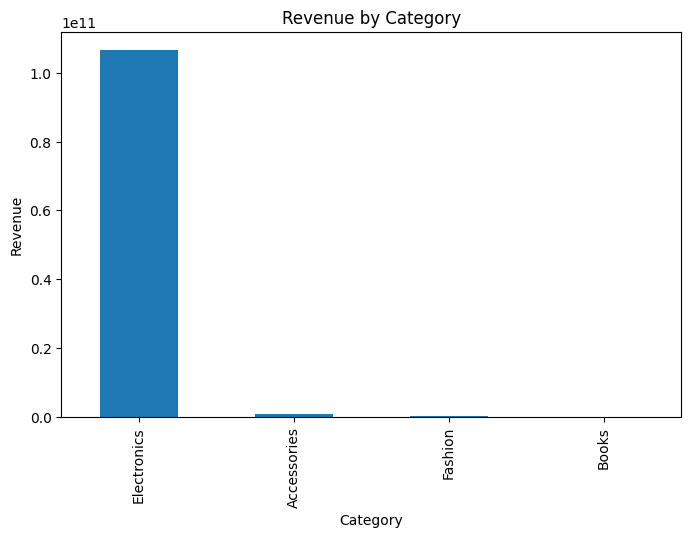

In [42]:
category_values.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

# 16.2 Monthly Revenue

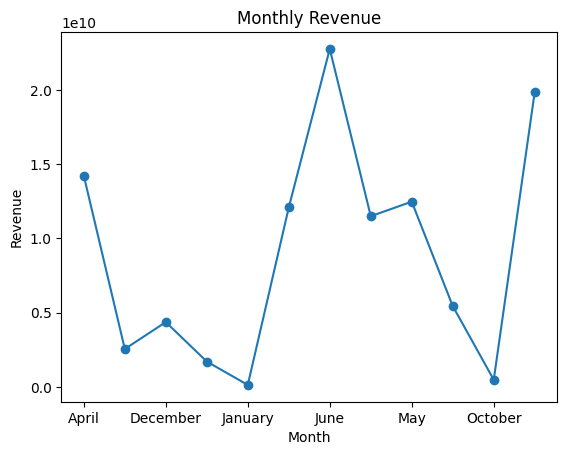

In [43]:
monthly_revenue.plot(
    kind="line",
    marker="o"
)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# 16.3 Age Distribution

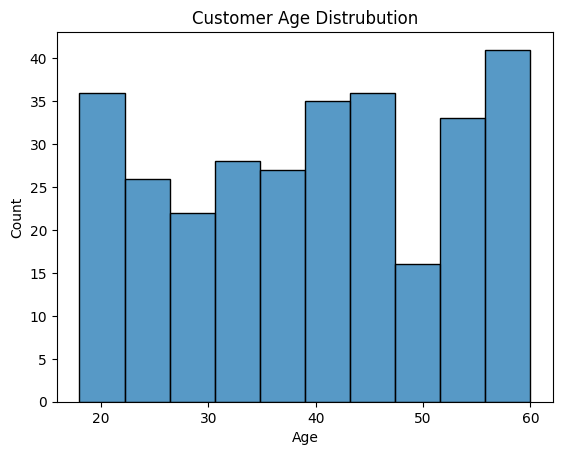

In [44]:
sns.histplot(
    df["Age"],
    bins = 10
)
plt.title("Customer Age Distrubution")
plt.show()

# 16.4 Gender Sales

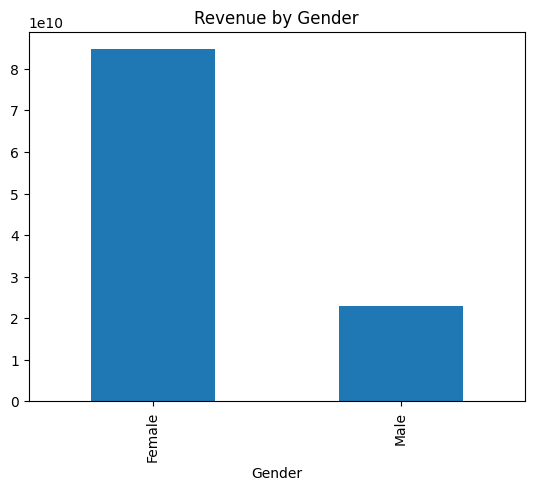

In [45]:
gender_sales = (
    df.groupby("Gender")["Final_Revenue"]
    .sum()
)
gender_sales.plot(
    kind="bar"
)
plt.title("Revenue by Gender")
plt.show()

# 16.5 Top 10 Products

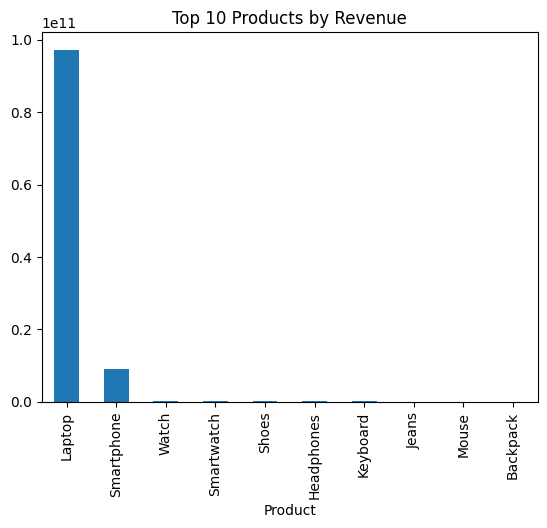

In [46]:
top_products = (
    df.groupby("Product")["Final_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

# 16.6 Discount vs Revenue

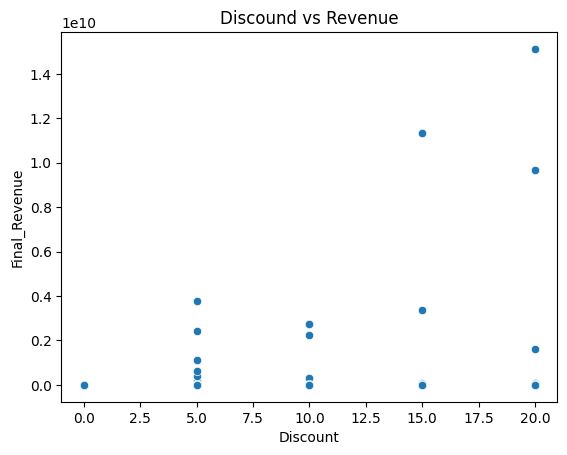

In [47]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Final_Revenue"
)
plt.title("Discound vs Revenue")
plt.show()

# 16.7 Box Plot

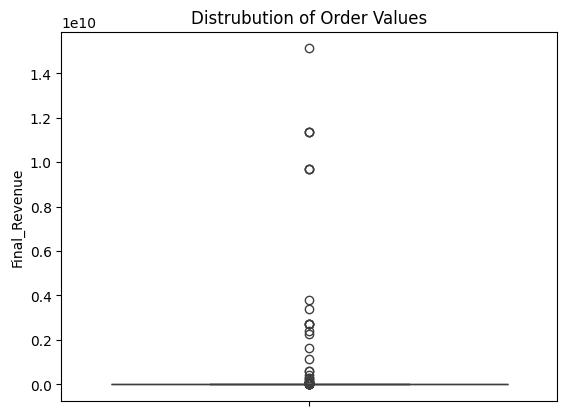

In [48]:
sns.boxplot(
    y=df["Final_Revenue"]
)
plt.title("Distrubution of Order Values")
plt.show()

# 🟢 STEP 17 — Statistics

In [49]:
df["Final_Revenue"].mean()

358801688.82883334

In [50]:
df["Final_Revenue"].max()

15125000000.0

In [51]:
df["Final_Revenue"].median()

897797.55

In [52]:
df["Final_Revenue"].std()

1762312922.9226298

In [53]:
df[
[
    "Age","Quantity","Price","Discount","Final_Revenue"
]
].corr()

,Age,Quantity,Price,Discount,Final_Revenue
Age,1.000000,-0.016384,-0.171821,-0.025094,-0.056703
Quantity,-0.016384,1.000000,0.086790,-0.021245,0.180510
Price,-0.171821,0.086790,1.000000,-0.066974,0.647282
Discount,-0.025094,-0.021245,-0.066974,1.000000,0.157326
Final_Revenue,-0.056703,0.180510,0.647282,0.157326,1.000000


In [54]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Gender', 'Age', 'City', 'Product',
       'Category', 'Quantity', 'Price', 'Discount', 'Payment_Method',
       'Revenue', 'Discount_Amount', 'Final_Revenue', 'Age_Group',
       'Month_Name', 'Discount_Group'],
      dtype='object')

# 🟢 STEP 19 — SQL JOIN

In [76]:
import pandas as pd
import sqlite3

df = pd.read_csv(
    "C:/Users/rudra/OneDrive/Desktop/data science/Machine learning/Ecommerce_Sales_Intelligence/data/ecommerce.csv"
)

df.head()

,Order_ID,Customer_ID,Date,Gender,Age,City,Product,Category,Quantity,Price,Discount,Payment_Method
0,ORD0001,CUST004,2025-02-27,Female,33,Vadodara,Wallet,Accessories,2,999,0,Net Banking
1,ORD0002,CUST055,2025-10-30,Male,19,Pune,Smartphone,Electronics,2,30000,5,Net Banking
2,ORD0003,CUST072,2025-01-14,Male,59,Jaipur,Watch,Accessories,4,3999,5,Cash on Delivery
3,ORD0004,CUST001,2025-05-23,Male,45,Delhi,Watch,Accessories,3,3999,5,Credit Card
4,ORD0005,CUST014,2025-06-22,Male,42,Pune,Book,Books,3,499,10,Net Banking


In [78]:
con = sqlite3.connect("ecommerce.db")

In [79]:
customers = df[
    ["Customer_ID", "Gender", "Age", "City"]
].drop_duplicates("Customer_ID")

customers.to_sql(
    "customers",
    con,
    if_exists="replace",
    index=False
)

96

In [80]:
products = df[
    ["Product", "Category", "Price"]
].drop_duplicates("Product")

products["Product_ID"] = range(1, len(products) + 1)

products.to_sql(
    "products",
    con,
    if_exists="replace",
    index=False
)

15

In [81]:
orders = df[
    ["Order_ID", "Customer_ID", "Date", "Product", "Quantity", "Discount", "Payment_Method"]
].copy()

orders = orders.merge(
    products[["Product", "Product_ID"]],
    on="Product",
    how="left"
)

orders = orders.drop(columns=["Product"])

orders.to_sql(
    "orders",
    con,
    if_exists="replace",
    index=False
)

300

In [82]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    con
)

,name
0,customers
1,products
2,orders


In [83]:
query = """
SELECT
    o.Order_ID,
    c.Customer_ID,
    c.City,
    p.Product,
    p.Category,
    o.Quantity,
    p.Price
FROM orders AS o
JOIN customers AS c
    ON o.Customer_ID = c.Customer_ID
JOIN products AS p
    ON o.Product_ID = p.Product_ID;
"""

result = pd.read_sql_query(query, con)

result.head()

,Order_ID,Customer_ID,City,Product,Category,Quantity,Price
0,ORD0001,CUST004,Vadodara,Wallet,Accessories,2,999
1,ORD0002,CUST055,Pune,Smartphone,Electronics,2,30000
2,ORD0003,CUST072,Jaipur,Watch,Accessories,4,3999
3,ORD0004,CUST001,Delhi,Watch,Accessories,3,3999
4,ORD0005,CUST014,Pune,Book,Books,3,499


# 🟢 STEP 20 — GROUP BY

In [89]:
query = """
SELECT 
    p.Category,
    SUM(o.Quantity * p.Price) AS Revenue
FROM orders AS o
JOIN products AS p
    ON o.Product_ID = p.Product_ID
GROUP BY p.Category
ORDER BY Revenue DESC;
"""

result = pd.read_sql_query(query, con)

result.head()




,Category,Revenue
0,Electronics,5766200
1,Accessories,483854
2,Fashion,407868
3,Books,50615


# 🟢 STEP 21 — HAVING

In [91]:
query = """
SELECT
    c.city,
    sum(o.Quantity * p.Price) AS Revenue
From orders o
JOIN customers c
    ON o.Customer_ID = c.Customer_ID
JOIN products p 
    ON o.Product_ID = p.Product_ID
GROUP BY c.city
HAVING Sum(o.Quantity * p.Price) > 100000;
"""
result = pd.read_sql_query(query,con)
result.head()

,City,Revenue
0,Ahmedabad,139509
1,Bengaluru,1294077
2,Chennai,449546
3,Delhi,564914
4,Hyderabad,656721


# 🟢 STEP 22 — CASE WHEN


In [92]:
query = """
SELECT
    Customer_ID,
    CASE
        WHEN Sum(Quantity * Price) >= 50000
            THEN 'High Value'
        WHEN Sum(Quantity * Price) >= 20000
            THEN 'Medium Value'
        Else 'Low Value'
    END AS Customer_Segment
FROM orders
JOIN products
     ON orders.Product_ID = products.Product_ID
GROUP BY Customer_ID;
"""
result = pd.read_sql_query(query,con)
result.head()

,Customer_ID,Customer_Segment
0,CUST001,Low Value
1,CUST002,Low Value
2,CUST003,Low Value
3,CUST004,Low Value
4,CUST005,Low Value


# 🟢 STEP 23 — SQL Subquery

In [93]:
query = """
SELECT *
From orders
where Quantity > (
      SELECT AVG(Quantity)
      FROM orders
);
"""
result = pd.read_sql_query(query,con)
result.head()

,Order_ID,Customer_ID,Date,Quantity,Discount,Payment_Method,Product_ID
0,ORD0003,CUST072,2025-01-14,4,5,Cash on Delivery,3
1,ORD0006,CUST094,2025-01-23,4,0,Net Banking,5
2,ORD0010,CUST021,2025-05-06,5,5,Debit Card,7
3,ORD0012,CUST092,2025-10-18,4,15,Credit Card,9
4,ORD0013,CUST032,2025-03-13,5,15,Debit Card,5


# 🟢 STEP 24 — Pandas + SQL Results Compare Karo

In [99]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [100]:
pandas_result = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
pandas_result

Category
Electronics    5766200
Accessories     483854
Fashion         407868
Books            50615
Name: Revenue, dtype: int64

In [102]:
query = """
SELECT 
    p.Category,
    SUM(o.Quantity * p.Price) AS Revenue
FROM orders AS o
JOIN products AS p
    ON o.Product_ID = p.Product_ID
GROUP BY p.Category
ORDER BY Revenue DESC;
"""

sql_result = pd.read_sql_query(query, con)

sql_result

,Category,Revenue
0,Electronics,5766200
1,Accessories,483854
2,Fashion,407868
3,Books,50615


In [103]:
highest_pandas = pandas_result.idxmax()

print("Pandas Highest Revenue Category:", highest_pandas)

highest_sql = sql_result.iloc[0]["Category"]

print("SQL Highest Revenue Category:", highest_sql)

Pandas Highest Revenue Category: Electronics
SQL Highest Revenue Category: Electronics


In [104]:
print("Pandas:", highest_pandas)
print("SQL:", highest_sql)

if highest_pandas == highest_sql:
    print("✅ Results Match")
else:
    print("❌ Results Do Not Match")

Pandas: Electronics
SQL: Electronics
✅ Results Match


In [106]:
total_orders = df["Order_ID"].nunique()

In [110]:
avg_order_value = total_revenue / total_orders

In [114]:
top_category = (
    df.groupby("Category")["Revenue"]
    .sum()
)

In [116]:
top_city = (
    df.groupby("City")["Revenue"]
      .sum()
      .idxmax()
)

In [118]:
top_product = (
    df.groupby("Product")["Revenue"]
      .sum()
      .idxmax()
)

In [119]:
print("========== E-COMMERCE KPI DASHBOARD ==========")

print(f"Total Revenue     : ₹{total_revenue:,.0f}")
print(f"Total Orders      : {total_orders}")
print(f"Average Order Value: ₹{avg_order_value:,.0f}")
print(f"Top Category      : {top_category}")
print(f"Top City          : {top_city}")
print(f"Top Product       : {top_product}")

========== E-COMMERCE KPI DASHBOARD ==========
Total Revenue     : ₹107,640,506,649
Total Orders      : 300
Average Order Value: ₹358,801,689
Top Category      : Category
Accessories     483854
Books            50615
Electronics    5766200
Fashion         407868
Name: Revenue, dtype: int64
Top City          : Bengaluru
Top Product       : Laptop
